# **MALDI-TOF Spectra Analysis – Plug & Play Notebook**

**Author:** Lucía Schmidt-Santiago  
**Date:** March 2025

This notebook provides a plug-and-play solution for loading, processing, visualizing, and modeling **MALDI-TOF** spectra. Functions for reading spectra are assumed to be pre-implemented in an external module.

### **📌 Step 0: Import Libraries**
Import necessary libraries and custom functions

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys
 
sys.path.append("utils")  # Ensure the script is accessible

# Import custom functions
from dataloader.DRIAMS_Manager import clean_database, DRIAMS_Manager, DRIAMS_Dataset
from utils.visualization import spectra_comparison, plot_pca, plot_tsne
from utils.preprocess import preprocess_spectra
from utils.spectrum_utils import split_dataset

In [2]:
# ########################## RUN ONLY ONCE ############################

# original_path = f"/Volumes/data_ml4ds/bacteria_id/relevant_datasets/10.5061/dryad.bzkh1899q/DRIAMS_ROOT"
# destination_path = f"/Volumes/usuarios_ml4ds/lschmidt/DRIAMS_PROCESSED"

# # Process DRIAMS Database to get the desired structure
# clean_database(original_path, destination_path)

### **📌 Step 1: Load the Dataset**
The **DRIAMS dataset** contains MALDI-TOF spectra for multiple bacteria.  

Let us create an object 'manager' that will help us contain all the DRIAMS data information and apply all required changes.

#### **1.1. Start by getting some data**
Use *get_taxonomy* to query informarmation regarding hospital, year, genus or species of the DRIAMS dataset

In [3]:
# Define dataset path
dataset_path = f"/export/data_ml4ds/bacteria_id/relevant_datasets/DRIAMS_PROCESSED_DATABASE"

# Initialize the DRIAMS manager
manager = DRIAMS_Manager(dataset_path)

# Check data
genus_in_driams_a = manager.get_taxonomy(dataset="DRIAMS_A")
print(f"Number of genus in DRIAMS_A: {len(genus_in_driams_a)}")
genus_species_driams_a = manager.get_taxonomy(dataset="DRIAMS_A", return_species=True)
print("Genus & Species in DRIAMS_A:", genus_species_driams_a)

Number of genus in DRIAMS_A: 202
Genus & Species in DRIAMS_A: [('Abiotrophia', 'Defectiva'), ('Achromobacter', 'Denitrificans'), ('Achromobacter', 'Insolitus'), ('Achromobacter', 'Piechaudii'), ('Achromobacter', 'Ruhlandii'), ('Achromobacter', 'Spanius'), ('Achromobacter', 'Xylosoxidans'), ('Acidaminococcus', 'Fermentans'), ('Acidaminococcus', 'Intestini'), ('Acidovorax', 'Temperans'), ('Acinetobacter', 'Baumannii'), ('Acinetobacter', 'Baylyi'), ('Acinetobacter', 'Bereziniae'), ('Acinetobacter', 'Calcoaceticus'), ('Acinetobacter', 'Guillouiae'), ('Acinetobacter', 'Haemolyticus'), ('Acinetobacter', 'Johnsonii'), ('Acinetobacter', 'Junii'), ('Acinetobacter', 'Lwoffii'), ('Acinetobacter', 'Nosocomialis'), ('Acinetobacter', 'Parvus'), ('Acinetobacter', 'Pittii'), ('Acinetobacter', 'Radioresistens'), ('Acinetobacter', 'Schindleri'), ('Acinetobacter', 'Tjernbergiae'), ('Acinetobacter', 'Ursingii'), ('Actinobacillus', 'Ureae'), ('Actinobaculum', 'Massiliense'), ('Actinomyces', 'Canis'), ('Act

Use *get_statistics* to obtain all info of available spectra in each hospital and year. With *.sort_values(by="TOTAL", ascending=False)* we can sort them in descending order by total of available spectra

In [4]:
# Get statistics
df_stats = manager.compute_statistics()
df_stats = df_stats.sort_values(by="TOTAL", ascending=False)
df_stats.head()

,GENUS,SPECIES,DRIAMS_A_2015,DRIAMS_A_2016,DRIAMS_A_2017,DRIAMS_A_2018,DRIAMS_B_2018,DRIAMS_C_2018,DRIAMS_D_2018,TOTAL
183,Escherichia,Coli,152,2034,3205,1990,839,927,2013,11160
118,Staphylococcus,Aureus,122,2031,2685,2227,542,738,2174,10519
120,Staphylococcus,Epidermidis,282,3032,3586,2578,460,21,374,10333
177,Klebsiella,Pneumoniae,89,1121,1723,1150,191,366,2151,6791
79,Pseudomonas,Aeruginosa,114,1489,1828,1477,197,357,362,5824


#### **1.2: Load Spectra for Two Bacteria**
We load **all MALDI-TOF spectra** for the following *Enterobacterales*:
- *E. coli*
- *K. pneumoniae*.

**The spectra contain intensity values for different m/z (mass-to-charge) ratios.**

In [5]:
# Load datasets for E. coli and K. pneumoniae
ecoli_dataset = DRIAMS_Dataset(manager, genus="Escherichia", species="Coli")
kleb_dataset = DRIAMS_Dataset(manager, genus="Klebsiella", species="Pneumoniae")

print(f"Loaded {len(ecoli_dataset)} E. coli spectra.")
print(f"Loaded {len(kleb_dataset)} K. pneumoniae spectra.")

Loaded 11160 E. coli spectra.
Loaded 6791 K. pneumoniae spectra.


Let's plot some spectra...

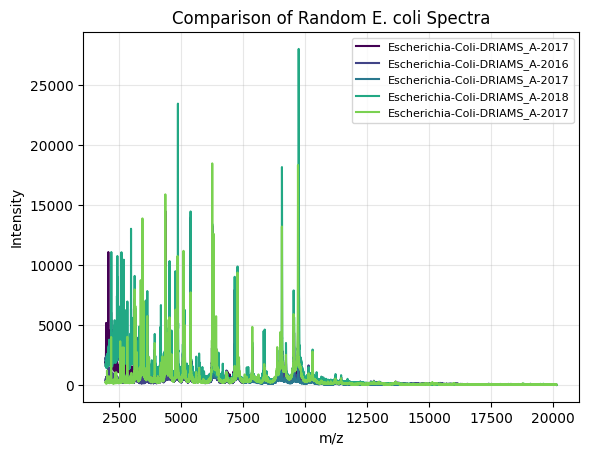

In [6]:
# Select random spectra from the dataset
random_ecolis = [ecoli_dataset[i] for i in np.random.choice(len(ecoli_dataset), size=5, replace=False)] 
spectra_comparison(random_ecolis, title="Comparison of Random E. coli Spectra")

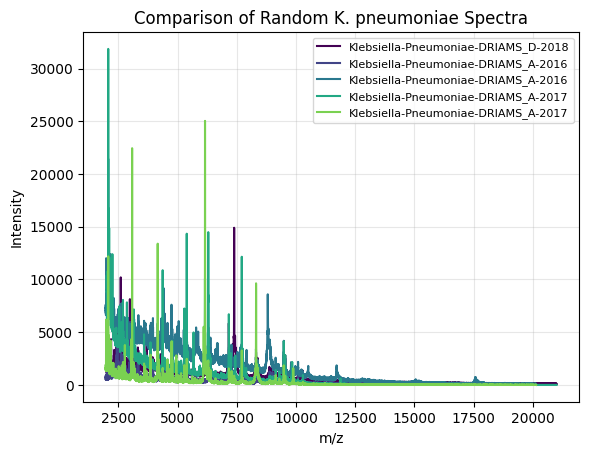

In [7]:
# Select random spectra from the dataset
random_klebs = [kleb_dataset[i] for i in np.random.choice(len(kleb_dataset), size=5, replace=False)]
spectra_comparison(random_klebs, title="Comparison of Random K. pneumoniae Spectra")

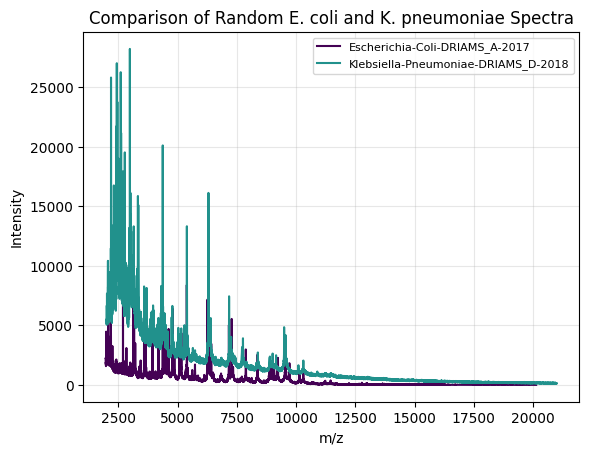

In [8]:
# Compare random spectra from both datasets
spectra_comparison([ecoli_dataset[np.random.choice(len(ecoli_dataset))], kleb_dataset[np.random.choice(len(kleb_dataset))]], 
                   title="Comparison of Random E. coli and K. pneumoniae Spectra")

### **📌 Step 2: Exploratory data anlysis (EDA)**

EDA plays a crucial role in understanding the structure, distribution, and variability of the data and it helps identify patterns, inconsistencies, and outliers.

#### **2.1: Determine dataset size and details**

First and foremost, it is important to determine how much data will be available, per hospital, year, and bacteria species. In the DRIAMS dataset there are no replicates, but in case there were, these should be handeled.

In [9]:
# Filter dataset statistics for E. coli and K. pneumoniae
df_selected = df_stats[df_stats["GENUS"].isin(["Escherichia", "Klebsiella"]) & 
                       df_stats["SPECIES"].isin(["Coli", "Pneumoniae"])].copy()

# Add a TOTAL row that sums all columns (except genus/species)
df_total = df_selected.drop(columns=["GENUS", "SPECIES"]).sum().to_frame().T
df_total.insert(0, "GENUS", "TOTAL")
df_total.insert(1, "SPECIES", "")

# Append TOTAL row to df_selected
df_selected = pd.concat([df_selected, df_total], ignore_index=True)

# Display result
print("\nDataset Size Summary for E. coli and K. pneumoniae")
display(df_selected)


Dataset Size Summary for E. coli and K. pneumoniae


,GENUS,SPECIES,DRIAMS_A_2015,DRIAMS_A_2016,DRIAMS_A_2017,DRIAMS_A_2018,DRIAMS_B_2018,DRIAMS_C_2018,DRIAMS_D_2018,TOTAL
0,Escherichia,Coli,152,2034,3205,1990,839,927,2013,11160
1,Klebsiella,Pneumoniae,89,1121,1723,1150,191,366,2151,6791
2,TOTAL,,241,3155,4928,3140,1030,1293,4164,17951


#### **2.2: Is my data balanced?**

In this notebook, we will try to identify between *Escherichia coli* and *Klebsiella pneumoniae*, so lets see if out data is balanced. Clearly, from the statistics above, we have almost half the number of samples for *K. pneumoniae* as we do for *E. coli*. Lets visualize this.

/tmp/ipykernel_17334/1958947090.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


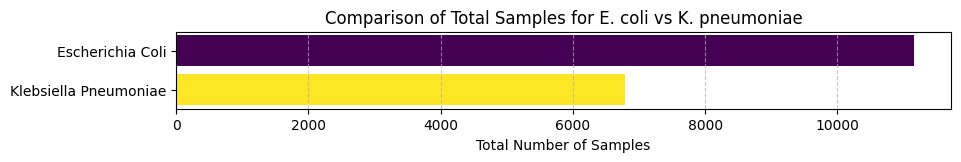

In [10]:
# Ensure species is a list of strings
species = (df_selected["GENUS"] + " " + df_selected["SPECIES"]).tolist()[:-1]  # Exclude TOTAL row

# Ensure totals are a list of integers
totals = df_selected["TOTAL"].astype(int).tolist()[:-1]  # Exclude TOTAL row

# Generate colors using the Viridis colormap
cmap = cm.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(species)))  # Generate colors for each species

# Plot horizontal bar chart
plt.figure(figsize=(10, 1))
plt.barh(species, totals, color=colors)  # Horizontal bar plot

# Add labels and title
plt.xlabel("Total Number of Samples")  # X-axis label
plt.title("Comparison of Total Samples for E. coli vs K. pneumoniae")  # Title

# Grid and style adjustments
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().invert_yaxis()  # Invert y-axis to have the highest bar on top

# Show the plot
plt.show()

#### **2.3: Data visualization**

Visualization of the data is very important for understanding it and taking informed decisions along the ML workflow.

Let's start with **PCA** (Principal Component Analysis) to visualize all spectra in 2D. The **goal** is to see if PCA can separate *E. coli* spectra from *K. pneumoniae* spectra.

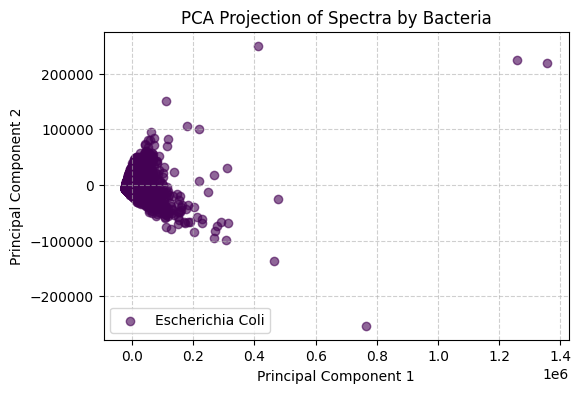

In [11]:
plot_pca(ecoli_dataset)

**t-SNE** to cluster similar spectra together. Here the **goal** is to answer: Can we visually distinguish the bacteria?

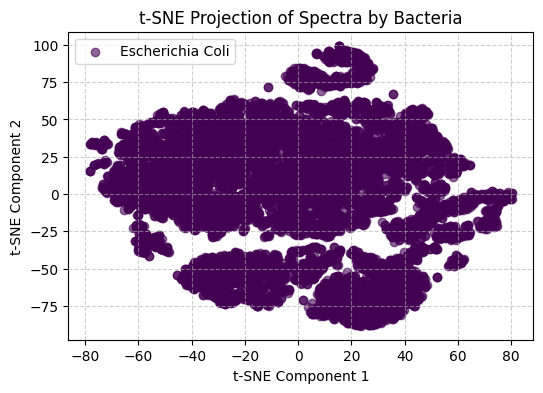

In [12]:
plot_tsne(ecoli_dataset)

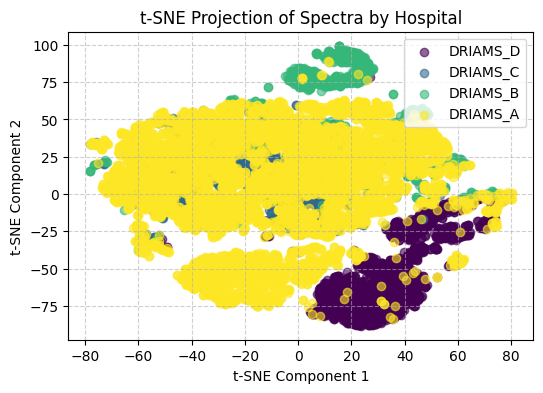

In [13]:
plot_tsne(ecoli_dataset, target="hospital")

### **📌 Step 3: Preprocessing**

Preprocessing directly incluences ML model performance. Standarized workflows need to be applied consistenly to all spectra in order to make experiments reproducible.

#### **3.0: Data splitting**

Before preprocessing, let's split the dataset into subgroups for training and testing. Taking into account the structure of the DRIAMS dataset, we kow that there are 4 different hospitals involved in it: DRIAMS_A, DRIAMS_B, DRIAMS_C, and DRIAMS_D. 

- We are going to take the DRIAMS_D set as an **Out-Of-Distribution set (OOD)**, where the trained model will be tested to see how it performs on data that is from a different source. 
- Then, the remaining data will be splitted **randomly** with a percentage of 0.2 into **training** and **testing** data. 
- The training data will be further splitted in a **Cross-Validation** process (CV) to tune the hyperparameters.

Let's start!

In [11]:
data = ecoli_dataset + kleb_dataset

# Split the dataset into training and OOD sets
train_set, OOD_set = split_dataset(data, split_by="hospital", key='DRIAMS_D')

print(f"Training samples: {len(train_set)}")
print(f"Testing (OOD) samples: {len(OOD_set)}")

Training samples: 13787
Testing (OOD) samples: 4164


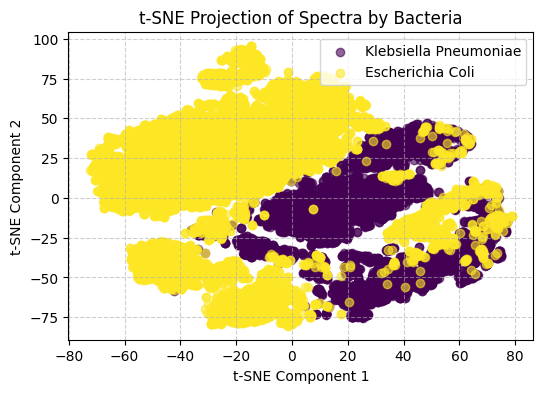

In [13]:
plot_tsne(data)

In [12]:
# Split the dataset into training and testing sets
training_data, test_set = split_dataset(train_set, split_by="random", perc=0.2)

print(f"Training samples: {len(training_data)}")
print(f"Testing samples: {len(test_set)}")

Training samples: 11029
Testing samples: 2758


#### **3.1: Standard Preprocessing**

Let's move on to the preprocessing steps:

- **Variance stabilization**
- **Smoothing**
- **Baseline subtraction**
- **Normalization**
- **Trimming**

In [13]:
from utils.preprocess import SequentialPreprocessor, VarStabilizer, Smoother, BaselineCorrecter, Trimmer, Binner, Normalizer

preprocess_pipeline = SequentialPreprocessor(VarStabilizer(method="sqrt"),
                                            Smoother(halfwindow=10),
                                            BaselineCorrecter(method="SNIP", snip_n_iter=20),
                                            Normalizer(sum=1),
                                            Trimmer())

In [14]:
training_prep = preprocess_spectra(training_data, preprocess_pipeline)

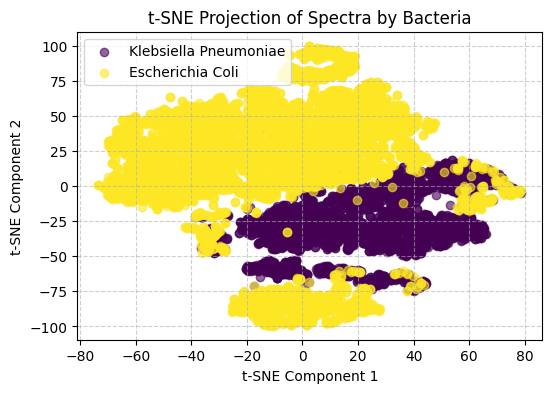

In [ ]:
# Plot the training data BEFORE being processed
plot_tsne(training_data)

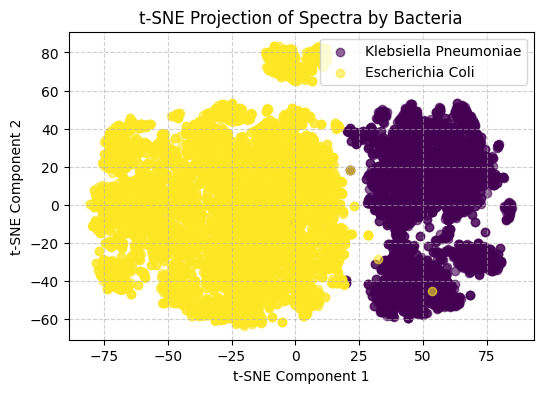

In [ ]:
# Plot the training data AFTER being processed
plot_tsne(training_prep)

#### **3.2: Binning**

Since MALDI-TOF MS data can vary in length, fixing the input size is a crucial step after standard preprocessing. There are two ways of approaching this: 

- **Binning**
- **Peak Selection**

For simplicity here, we are going to use the binning technique, using a window of 3 Da to obtain a vector of length 6,000.

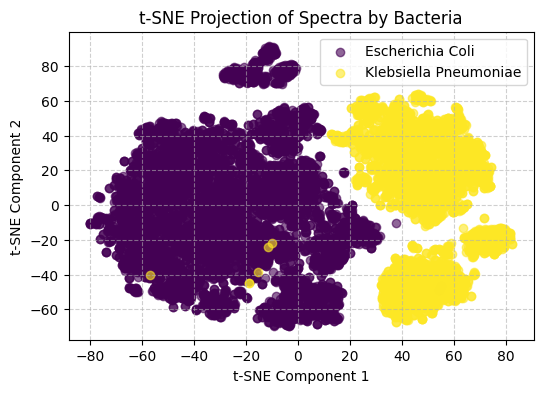

In [15]:
binning_step = 3
binning = Binner(step=binning_step)

training_binned = preprocess_spectra(training_prep, binning)
plot_tsne(training_binned)

### **📌 Step 4: Model training**

This section will be divided into: 

- **4.1: Address data imbalance**
- **4.2: Model selection**
- **4.3: Hyperparameter tuning**
- **4.4: Model training**

#### **4.1: Address data imbalance**

There are two ways: 
- **Sampling**: either oversample the minority class or undersampling the majority one.
- **Loss weightening**: incorporate imbalance-aware loss functions

In [24]:
def extract_features_and_species_labels(data):
    X = []
    y = []

    for spectrum, label in data:
        # Use intensity vector as features
        X.append(spectrum.intensity)

        # Extract just the species name
        genus, species, *_ = label.split("-")
        y.append(f"{genus} {species}")  # e.g. "Escherichia Coli"

    return np.array(X), np.array(y)

X_train, y_train = extract_features_and_species_labels(training_binned)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, balanced_accuracy_score

# Define balanced accuracy as the scoring metric
balanced_acc = make_scorer(balanced_accuracy_score)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

# Run grid search with balanced accuracy
clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring=balanced_acc,
    cv=3,
    n_jobs=-1
)

# Train
clf.fit(X_resampled, y_resampled)

# Best model
print("Best parameters:", clf.best_params_)
print("Best balanced accuracy score:", clf.best_score_)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, make_scorer
import numpy as np

# 1. Preprocess the test set
test_preprocessed = preprocess_spectra(test_set, preprocess_pipeline)

# 2. Extract features and labels
X_test = np.array([spectrum.intensity for spectrum, _ in test_preprocessed])
y_test = [label.split("-")[1] for _, label in test_preprocessed]  # Only the species

# 3. Initialize Random Forest with best hyperparameters
rf_best = RandomForestClassifier(clf.best_params_, random_state=42)

# 4. Perform cross-validation with balanced accuracy
scores = cross_val_score(
    rf_best, X_test, y_test, 
    cv=5, 
    scoring=make_scorer(balanced_accuracy_score)
)

# 5. Show results
print("Balanced Accuracy scores (CV):", scores)
print("Mean Balanced Accuracy:", np.mean(scores))